# 隔夜净额（抵消后）与市盈率 / 市净率：相关性与阈值过滤

**问题**：净额最差的一批标的，是否对应更高 PE/PB？设定 PE/PB 上限规则时，能否在**挡住差标的**的同时，看**净额合计/均值**是否改善、**误伤了多少好标的的收益**？

**数据**：`overnight_pnl_by_symbol.csv`；`data/<日期>/quote/basic/*.csv`（`pe` 静、`pb`）。

环境变量：`OVERNIGHT_TEXT_DIR`、`VALUATION_DATA_DATE`。


In [15]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "qlib_lab").is_dir():
        return here
    if (here.parent / "qlib_lab").is_dir():
        return here.parent
    return here


def latest_data_date(data_root: Path) -> str | None:
    if not data_root.is_dir():
        return None
    dirs = [p.name for p in data_root.iterdir() if p.is_dir() and p.name.isdigit() and len(p.name) == 8]
    return max(dirs) if dirs else None


def qlib_to_basic_stem(sym: str) -> str:
    s = str(sym).strip().upper()
    if len(s) > 2 and s[:2] in ("SH", "SZ", "BJ"):
        return f"{s[2:]}_{s[:2]}"
    return s.replace(".", "_")


REPO = find_repo_root()
DATA = REPO / "data"
TEXT_DIR = Path(os.environ.get("OVERNIGHT_TEXT_DIR", REPO / "qlib_runs" / "plots" / "text"))
PNL_CSV = TEXT_DIR / "overnight_pnl_by_symbol.csv"
DATE_STR = os.environ.get("VALUATION_DATA_DATE") or latest_data_date(DATA)

# 定义「净额差」：全样本中 net_pnl_total 最低的分位以下
BAD_QUANTILE = 0.25  # 最差 25% 视为 bad bucket（可改 0.2 / 0.1）

print("仓库:", REPO)
print("PNL:", PNL_CSV)
print("估值日期:", DATE_STR)


仓库: /Users/yi/Projects/quant-data-foundry
PNL: /Users/yi/Projects/quant-data-foundry/qlib_runs/plots/text/overnight_pnl_by_symbol.csv
估值日期: 20260410


In [16]:
if DATE_STR is None:
    raise SystemExit("无 data 日期目录")
if not PNL_CSV.is_file():
    raise FileNotFoundError(PNL_CSV)

pnl = pd.read_csv(PNL_CSV, encoding="utf-8")
pnl["net_pnl_total"] = pd.to_numeric(pnl["net_pnl_total"], errors="coerce")
pnl = pnl.dropna(subset=["net_pnl_total", "symbol"])

basic_dir = DATA / DATE_STR / "quote" / "basic"
if not basic_dir.is_dir():
    raise FileNotFoundError(basic_dir)

rows = []
miss = 0
for sym in pnl["symbol"].astype(str).unique():
    fp = basic_dir / f"{qlib_to_basic_stem(sym)}.csv"
    if not fp.is_file():
        miss += 1
        continue
    df = pd.read_csv(fp, encoding="utf-8")
    if df.empty:
        miss += 1
        continue
    if "trade_date" in df.columns:
        df = df.sort_values("trade_date")
    last = df.iloc[-1]
    rows.append({"symbol": sym, "pe": last.get("pe"), "pb": last.get("pb")})

val = pd.DataFrame(rows)
for c in ("pe", "pb"):
    val[c] = pd.to_numeric(val[c], errors="coerce")

m = pnl.merge(val, on="symbol", how="inner")
m["pe_pos"] = m["pe"].where(m["pe"] > 0)
m["pb_pos"] = m["pb"].where(m["pb"] > 0)

sub = m.dropna(subset=["net_pnl_total", "pe_pos", "pb_pos"]).copy()
print(f"PNL 行 {len(pnl)}；匹配 basic {len(m)}；有效 pe>0,pb>0: {len(sub)}；缺 basic文件约 {miss}")
sub.head()

PNL 行 407；匹配 basic 407；有效 pe>0,pb>0: 367；缺 basic文件约 0


,Unnamed: 0,symbol,n_overnight_legs,net_pnl_total,gross_loss_from_legs,gross_profit_from_legs,abs_cumulative_loss,rank_worst_net_pnl,pe,pb,pe_pos,pb_pos
0,307,SZ300394,123,-50992.870605,-138053.871366,87061.000760,138053.871366,1,138.3132,50.6748,138.3132,50.6748
1,132,SZ300251,21,-35912.258568,-44372.720032,8460.461465,44372.720032,2,162.0418,4.4025,162.0418,4.4025
2,16,SZ300748,28,-29933.410521,-42078.608070,12145.197548,42078.608070,3,63.7491,6.0909,63.7491,6.0909
3,39,SH600026,26,-21145.092634,-29374.826656,8229.734022,29374.826656,4,34.6000,3.0102,34.6000,3.0102
4,242,SZ002371,76,-20344.744815,-48903.935097,28559.190282,48903.935097,5,60.9711,9.5091,60.9711,9.5091


In [17]:
if len(sub) < 30:
    print("警告：有效样本较少，阈值与相关结论仅作参考")

q_bad = sub["net_pnl_total"].quantile(BAD_QUANTILE)
sub["is_bad"] = (sub["net_pnl_total"] <= q_bad).astype(int)
base_bad_rate = float(sub["is_bad"].mean())

corr = pd.DataFrame(
    {
        "Pearson": [
            sub["net_pnl_total"].corr(sub["pe_pos"]),
            sub["net_pnl_total"].corr(sub["pb_pos"]),
        ],
        "Spearman": [
            sub["net_pnl_total"].corr(sub["pe_pos"], method="spearman"),
            sub["net_pnl_total"].corr(sub["pb_pos"], method="spearman"),
        ],
    },
    index=["vs市盈率(静)", "vs 市净率"],
)
print(f"最差 {BAD_QUANTILE:.0%} 分位 临界 net_pnl_total={q_bad:.4g}；全样本标为 bad 的比例 {base_bad_rate:.1%}")
corr

最差 25% 分位 临界 net_pnl_total=-1201；全样本标为 bad 的比例 25.1%


,Pearson,Spearman
vs市盈率(静),-0.030021,-0.152665
vs 市净率,-0.216409,-0.151031


In [18]:
# bad vs non-bad 的估值中位数对比
cmp = sub.groupby("is_bad").agg(
    n=("symbol", "count"),
    median_pe=("pe_pos", "median"),
    median_pb=("pb_pos", "median"),
    mean_net=("net_pnl_total", "mean"),
)
cmp.index = cmp.index.map({0: "非 bad（净额较好）", 1: "bad（净额最差分位）"})
cmp

,n,median_pe,median_pb,mean_net
is_bad,,,,
非 bad（净额较好）,275,26.48250,2.3952,1787.056311
bad（净额最差分位）,92,31.30755,3.0079,-6384.556803


In [19]:
def exclusion_mask(df: pd.DataFrame, cap_pe: float, cap_pb: float) -> pd.Series:
    return (df["pe_pos"] > cap_pe) | (df["pb_pos"] > cap_pb)


pe_caps = [15, 20, 25, 30, 40, 50, 80]
pb_caps = [1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0]

bad = sub["is_bad"] == 1
good = sub["is_bad"] == 0
net_all = float(sub["net_pnl_total"].sum())
mean_net_all = float(sub["net_pnl_total"].mean())
bad_net_sum = float(sub.loc[bad, "net_pnl_total"].sum()) if bad.any() else 0.0
good_net_sum = float(sub.loc[good, "net_pnl_total"].sum()) if good.any() else 0.0

records = []
for cpe in pe_caps:
    for cpb in pb_caps:
        ex = exclusion_mask(sub, cpe, cpb)
        kept = ~ex
        hit_bad = float(ex[bad].mean()) if bad.any() else np.nan
        hit_good = float(ex[good].mean()) if good.any() else np.nan
        ex_rate = float(ex.mean())
        lift = (hit_bad / ex_rate) if ex_rate > 1e-9 else np.nan

        sum_kept = float(sub.loc[kept, "net_pnl_total"].sum())
        sum_excl = float(sub.loc[ex, "net_pnl_total"].sum())
        delta_sum = sum_kept - net_all
        rel_delta_sum = delta_sum / max(abs(net_all), 1e-9)

        mean_kept = float(sub.loc[kept, "net_pnl_total"].mean()) if kept.any() else np.nan
        delta_mean = mean_kept - mean_net_all

        bad_excl_net = float(sub.loc[bad & ex, "net_pnl_total"].sum())
        good_excl_net = float(sub.loc[good & ex, "net_pnl_total"].sum())
        bad_loss_captured = (
            (bad_excl_net / bad_net_sum) if bad_net_sum < -1e-9 else np.nan
        )

        records.append(
            {
                "cap_pe": cpe,
                "cap_pb": cpb,
                "排除比例_全样本": ex_rate,
                "bad中被排除比例": hit_bad,
                "非bad中被排除比例": hit_good,
                "lift_bad_vs_base": lift,
                "保留池净额合计": sum_kept,
                "delta_净额合计_vs全样本": delta_sum,
                "相对全样本_净额改善率": rel_delta_sum,
                "保留池单标的均值净额": mean_kept,
                "delta_均值净额_vs全样本": delta_mean,
                "挡掉的bad净额合计": bad_excl_net,
                "误挡的好标的净额合计": good_excl_net,
                "bad桶损失中被挡比例": bad_loss_captured,
            }
        )

grid = pd.DataFrame(records)
grid["score_挡差_少误伤"] = grid["bad中被排除比例"] - grid["非bad中被排除比例"]
grid["score_含收益"] = (
    grid["bad桶损失中被挡比例"].fillna(0)
    - 0.5 * grid["非bad中被排除比例"].fillna(0)
    + 0.5 * grid["相对全样本_净额改善率"].fillna(0).clip(-1, 1)
)
cols_show = [
    "cap_pe",
    "cap_pb",
    "bad中被排除比例",
    "非bad中被排除比例",
    "相对全样本_净额改善率",
    "delta_均值净额_vs全样本",
    "bad桶损失中被挡比例",
    "误挡的好标的净额合计",
    "score_含收益",
]
print(
    f"基准：全样本净额合计={net_all:.4g}，均值={mean_net_all:.4g}；"
    f"bad桶合计={bad_net_sum:.4g}，非bad合计={good_net_sum:.4g}"
)
grid[cols_show].nlargest(15, "score_含收益")



基准：全样本净额合计=-9.594e+04，均值=-261.4；bad桶合计=-5.874e+05，非bad合计=4.914e+05


,cap_pe,cap_pb,bad中被排除比例,非bad中被排除比例,相对全样本_净额改善率,delta_均值净额_vs全样本,bad桶损失中被挡比例,误挡的好标的净额合计,score_含收益
35,50,1.5,0.934783,0.720000,2.040853,1464.522998,0.978518,378964.544740,1.118518
42,80,1.5,0.923913,0.720000,2.015014,1420.689244,0.974298,378964.544740,1.114298
28,40,1.5,0.934783,0.730909,2.006282,1468.181126,0.978518,382281.223120,1.113064
21,30,1.5,0.934783,0.745455,1.853603,1338.960309,0.978518,396929.075800,1.105791
14,25,1.5,0.934783,0.756364,1.831751,1354.525289,0.978518,399025.472857,1.100337
22,30,2.0,0.847826,0.665455,1.753093,943.025016,0.925350,375341.804360,1.092623
15,25,2.0,0.858696,0.683636,1.779871,1009.611778,0.932021,376691.385830,1.090203
7,20,1.5,0.945652,0.785455,1.689267,1294.653872,0.982058,414774.294750,1.089331
36,50,2.0,0.815217,0.621818,1.752314,857.909509,0.896077,358222.108961,1.085168
1,15,2.0,0.934783,0.792727,1.682532,1300.799092,0.980160,414305.586754,1.083796


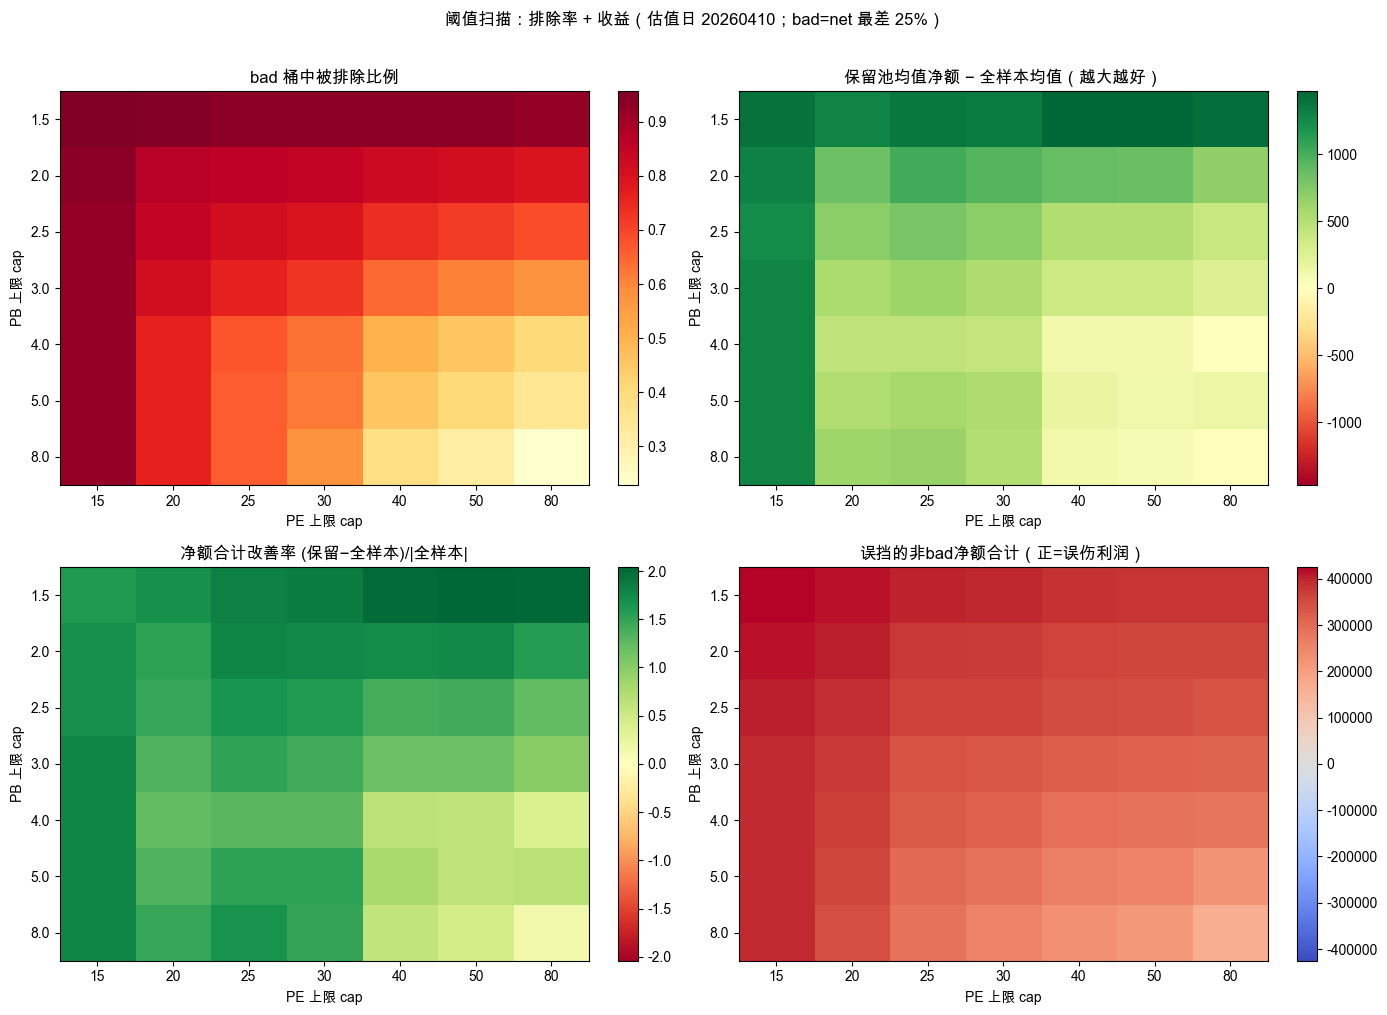

In [20]:
mat_hit = grid.pivot(index="cap_pb", columns="cap_pe", values="bad中被排除比例")
mat_dmean = grid.pivot(index="cap_pb", columns="cap_pe", values="delta_均值净额_vs全样本")
mat_rel = grid.pivot(index="cap_pb", columns="cap_pe", values="相对全样本_净额改善率")

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def _heat(ax, data, title, cmap, symmetric_zero: bool = False):
    v = data.values.astype(float)
    if symmetric_zero:
        m = float(np.nanmax(np.abs(v)))
        if m < 1e-12:
            m = 1e-12
        vmin, vmax = -m, m
    else:
        vmin, vmax = float(np.nanmin(v)), float(np.nanmax(v))
    im = ax.imshow(v, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    ax.set_xlabel("PE 上限 cap")
    ax.set_ylabel("PB 上限 cap")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
_heat(axes[0, 0], mat_hit, "bad 桶中被排除比例", "YlOrRd", symmetric_zero=False)
_heat(axes[0, 1], mat_dmean, "保留池均值净额 − 全样本均值（越大越好）", "RdYlGn", symmetric_zero=True)
_heat(axes[1, 0], mat_rel, "净额合计改善率 (保留−全样本)/|全样本|", "RdYlGn", symmetric_zero=True)
mat_mis = grid.pivot(index="cap_pb", columns="cap_pe", values="误挡的好标的净额合计")
_heat(axes[1, 1], mat_mis, "误挡的非bad净额合计（正=误伤利润）", "coolwarm", symmetric_zero=True)

fig.suptitle(
    f"阈值扫描：排除率 + 收益（估值日 {DATE_STR}；bad=net 最差 {BAD_QUANTILE:.0%}）",
    y=1.01,
)
fig.tight_layout()
plt.show()



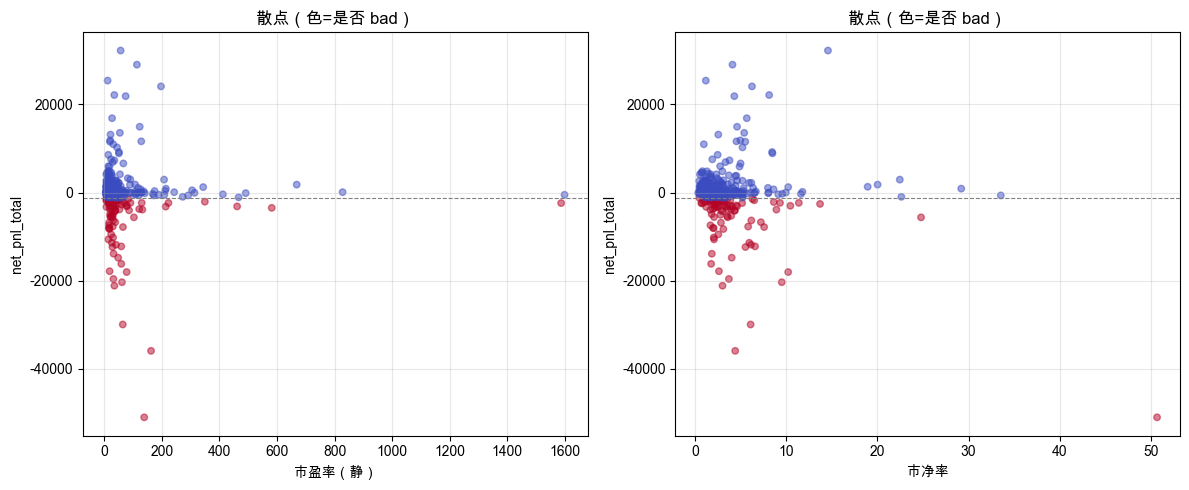

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(sub["pe_pos"], sub["net_pnl_total"], c=sub["is_bad"], cmap="coolwarm", alpha=0.5, s=22)
ax.axhline(q_bad, color="gray", ls="--", lw=0.8)
ax.set_xlabel("市盈率（静）")
ax.set_ylabel("net_pnl_total")
ax.set_title("散点（色=是否 bad）")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(sub["pb_pos"], sub["net_pnl_total"], c=sub["is_bad"], cmap="coolwarm", alpha=0.5, s=22)
ax.axhline(q_bad, color="gray", ls="--", lw=0.8)
ax.set_xlabel("市净率")
ax.set_ylabel("net_pnl_total")
ax.set_title("散点（色=是否 bad）")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 如何读结果

- **相关**：|ρ| 小不代表阈值无**非线性**收益，需看金额指标。
- **排除率**：仅看 bad/非bad 被挡比例不够，必须结合**净额与均值**。
- **收益维度**
  - **delta_净额合计_vs全样本** = 保留池合计 − 全样本合计 = −被挡标的净额合计。
  - **相对全样本_净额改善率**：除以 |全样本净额|，便于比量级。
  - **delta_均值净额_vs全样本**：保留池单标的平均净额变化（等权视角）。
  - **bad桶损失中被挡比例**：bad 桶净额多为负；越接近 1 越多吃掉最差分位的亏损额。
  - **误挡的好标的净额合计**：被挡住的非 bad 净额之和；**为正**说明误伤里有不少赚钱标的。
- **热力图**：上行右、下行左看**收益**；下行右看**误伤金额**；与上行左排除率对照。
- **score_含收益**：启发式综合分，请以热力图为准调参。
- **局限**：估值截面 vs 回测累计；非组合真实权重。
